In [1]:
import pandas as pd
rfm_df = pd.read_csv("customer_rfm_features.csv")

In [2]:
rfm_df.head()

,Customer ID,recency,frequency,monetary
0,12346.0,325,12,77556.46
1,12347.0,1,8,5633.32
2,12348.0,74,5,2019.40
3,12349.0,18,4,4428.69
4,12350.0,309,1,334.40


# Selecting Features + Scale 

In [4]:
from sklearn.preprocessing import StandardScaler

rfm_features = rfm_df[["recency", "frequency", "monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [5]:
rfm_scaled.shape

(5878, 3)

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)


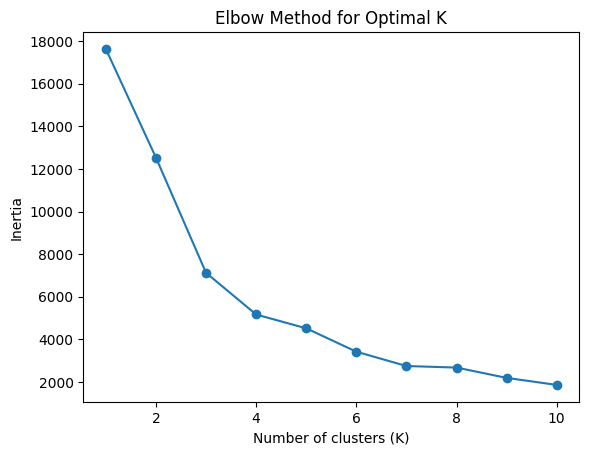

In [7]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(rfm_scaled)


In [9]:
rfm_df["cluster"] = cluster_labels


In [10]:
rfm_df.head()


,Customer ID,recency,frequency,monetary,cluster
0,12346.0,325,12,77556.46,1
1,12347.0,1,8,5633.32,1
2,12348.0,74,5,2019.40,1
3,12349.0,18,4,4428.69,1
4,12350.0,309,1,334.40,0


In [11]:
cluster_profile = (
    rfm_df
    .groupby("cluster")[["recency", "frequency", "monetary"]]
    .mean()
    .reset_index()
)

cluster_profile


,cluster,recency,frequency,monetary
0,0,462.032032,2.212212,765.244446
1,1,66.005728,7.307993,3009.402451
2,2,24.942857,103.714286,83086.079771
3,3,2.500000,212.500000,436835.792500


In [12]:
cluster_map = {
    0: "At_Risk",
    1: "Potential_Loyalist",
    2: "Loyal",
    3: "Champion"
}

rfm_df["segment"] = rfm_df["cluster"].map(cluster_map)


In [13]:
rfm_df[["Customer ID", "cluster", "segment"]].head()


,Customer ID,cluster,segment
0,12346.0,1,Potential_Loyalist
1,12347.0,1,Potential_Loyalist
2,12348.0,1,Potential_Loyalist
3,12349.0,1,Potential_Loyalist
4,12350.0,0,At_Risk


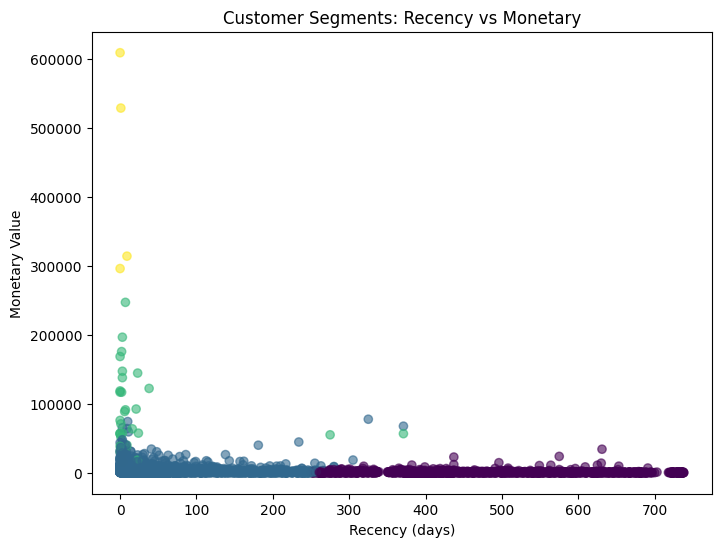

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    rfm_df["recency"],
    rfm_df["monetary"],
    c=rfm_df["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.title("Customer Segments: Recency vs Monetary")
plt.show()


In [15]:
rfm_df.to_csv(
    "customer_segments.csv",
    index=False
)
